>**🔱 大家好，我是 👉 [K同学啊](https://mtyjkh.blog.csdn.net/)，[《深度学习100例》](https://blog.csdn.net/qq_38251616/category_11068756.html)系列将持续更新 欢迎 点赞👍、收藏⭐、关注👀**

本文将采用 `GAN` 模型实现手写数字的生成，重点是了解 `GAN` 模型的结构及其搭建方法。

# 一、前期工作

🔥本文 GitHub [https://github.com/kzbkzb/Python-AI](https://github.com/kzbkzb/Python-AI) 已收录

- 作者：[K同学啊](https://mp.weixin.qq.com/s/NES9RhtAhbX_jsmGua28dA)
- 来自专栏：《深度学习100例》-Tensorflow2版本

我的环境：

- 语言环境：Python3.6.5
- 编译器：jupyter notebook
- 深度学习环境：TensorFlow2.4.1

🚀 深度学习新人必看：

1. [小白入门深度学习 | 第一篇：配置深度学习环境](https://mtyjkh.blog.csdn.net/article/details/118575238)
2. [小白入门深度学习 | 第二篇：编译器的使用-Jupyter Notebook](https://mtyjkh.blog.csdn.net/article/details/118814364)

## 1. 设置GPU

如果使用的是CPU可以注释掉这部分的代码。

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)  #设置GPU显存用量按需使用
    tf.config.set_visible_devices([gpus[0]],"GPU")
    
# 打印显卡信息，确认GPU可用
print(gpus)

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from tensorflow.keras import layers, datasets, Sequential, Model, optimizers
from tensorflow.keras.layers import LeakyReLU, UpSampling2D, Conv2D

import matplotlib.pyplot as plt
import numpy             as np
import sys,os,pathlib

## 2. 定义训练参数

In [3]:
img_shape  = (28, 28, 1)
latent_dim = 200

# 二、什么是生成对抗网络

## 1. 简单介绍

`生成对抗网络（GAN）` 包含生成器和判别器，两个模型通过对抗训练不断学习、进化。

- `生成器(Generator)`：生成数据（大部分情况下是图像），目的是“骗过”判别器。

- `鉴别器(Discriminator)`：判断这张图像是真实的还是机器生成的，目的是找出生成器生成的“假数据”。

## 2. 应用领域

GAN 的应用十分广泛，它的应用包括图像合成、风格迁移、照片修复以及照片编辑，数据增强等等。

**1）风格迁移**

图像风格迁移是将图像A的风格转换到图像B中去，得到新的图像。

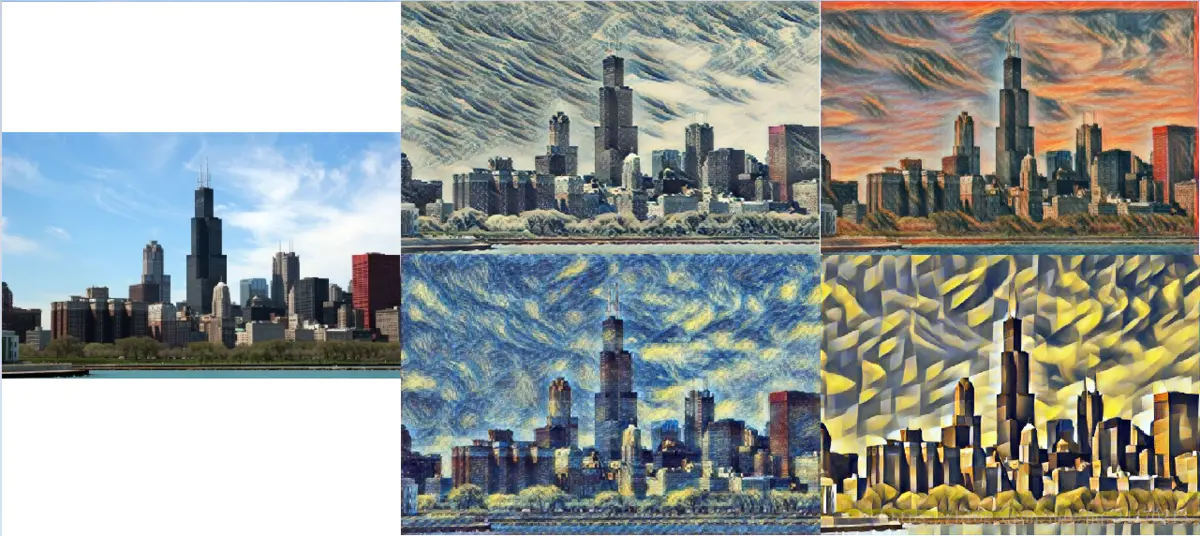

**2）图像生成**

GAN 不但能生成人脸，还能生成其他类型的图片，比如漫画人物。

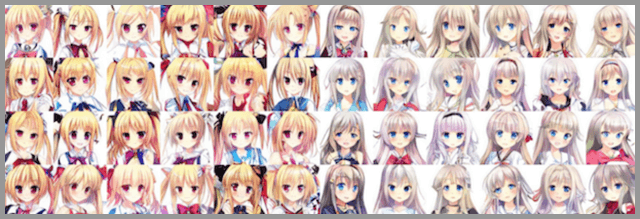

# 三、网络结构

简单来讲，就是用生成器生成手写数字图像，用鉴别器鉴别图像的真假。二者相互对抗学习（卷），在对抗学习（卷）的过程中不断完善自己，直至生成器可以生成以假乱真的图片（鉴别器无法判断其真假）。结构图如下：

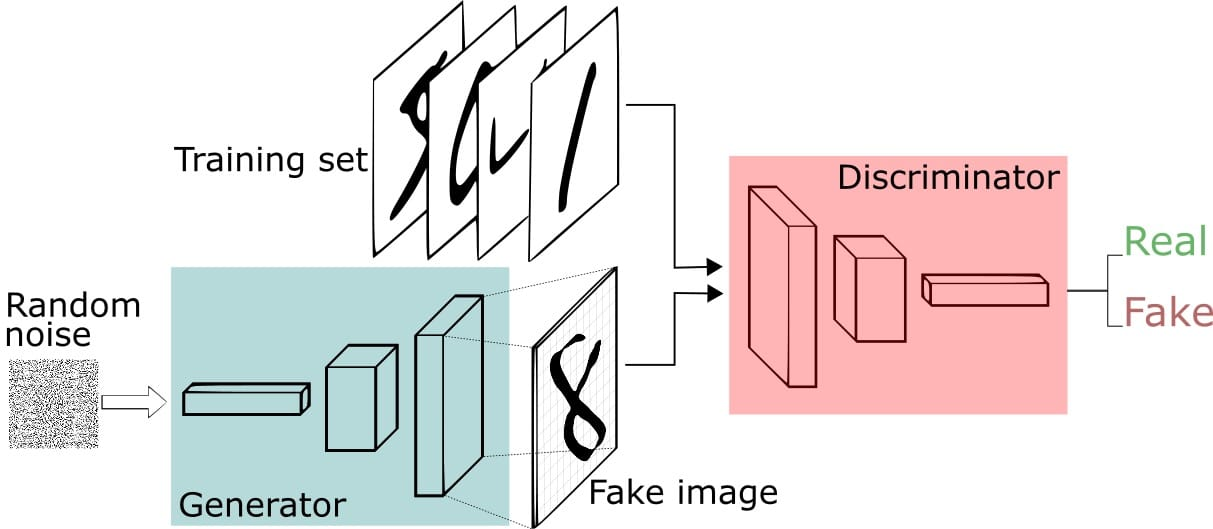

**GAN步骤：**

- 1.生成器（Generator）接收随机数并返回生成图像。
- 2.将生成的数字图像与实际数据集中的数字图像一起送到鉴别器（Discriminator）。
- 3.鉴别器（Discriminator）接收真实和假图像并返回概率，0到1之间的数字，1表示真，0表示假。

# 四、构建生成器

In [4]:
def build_generator():
    # ======================================= #
    #     生成器，输入一串随机数字生成图片
    # ======================================= #
    model = Sequential([
        layers.Dense(256, input_dim=latent_dim),
        layers.LeakyReLU(alpha=0.2),               # 高级一点的激活函数
        layers.BatchNormalization(momentum=0.8),   # BN 归一化
        
        layers.Dense(512),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(momentum=0.8),
        
        layers.Dense(1024),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(momentum=0.8),
        
        layers.Dense(np.prod(img_shape), activation='tanh'),
        layers.Reshape(img_shape)
    ])

    noise = layers.Input(shape=(latent_dim,))
    img = model(noise)

    return Model(noise, img)

# 五、构建鉴别器

In [5]:
def build_discriminator():
    # ===================================== #
    #   鉴别器，对输入的图片进行判别真假
    # ===================================== #
    model = Sequential([
        layers.Flatten(input_shape=img_shape),
        layers.Dense(512),
        layers.LeakyReLU(alpha=0.2),
        layers.Dense(256),
        layers.LeakyReLU(alpha=0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    img = layers.Input(shape=img_shape)
    validity = model(img)

    return Model(img, validity)

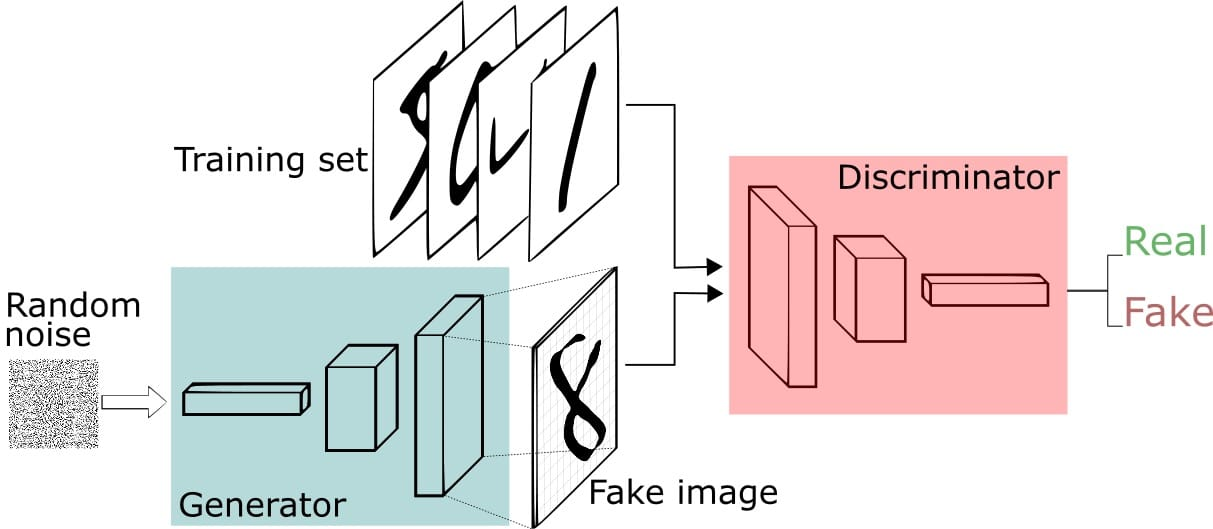

- 鉴别器训练原理：通过对输入的图片进行鉴别，从而达到提升的效果
- 生成器训练原理：通过鉴别器对其生成的图片进行鉴别，来实现提升

In [6]:
# 创建判别器
discriminator = build_discriminator()
# 定义优化器
optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator.compile(loss='binary_crossentropy',
                      optimizer=optimizer,
                      metrics=['accuracy'])

# 创建生成器 
generator = build_generator()
gan_input = layers.Input(shape=(latent_dim,))
img = generator(gan_input)

# 对生成的假图片进行预测
validity = discriminator(img)
combined = Model(gan_input, validity)
combined.compile(loss='binary_crossentropy', optimizer=optimizer)

# 六、训练模型

## 1. 保存样例图片

In [7]:
def sample_images(epoch):
    """
    保存样例图片
    """
    row, col = 4, 4
    noise = np.random.normal(0, 1, (row*col, latent_dim))
    gen_imgs = generator.predict(noise)

    fig, axs = plt.subplots(row, col)
    cnt = 0
    for i in range(row):
        for j in range(col):
            axs[i,j].imshow(gen_imgs[cnt, :,:,0], cmap='gray')
            axs[i,j].axis('off')
            cnt += 1
    fig.savefig("images/%05d.png" % epoch)
    plt.close()

## 2. 训练模型

`train_on_batch`：函数接受单批数据，执行反向传播，然后更新模型参数，该批数据的大小可以是任意的，即，它不需要提供明确的批量大小，属于精细化控制训练模型。

In [8]:
def train(epochs, batch_size=128, sample_interval=50):
    # 加载数据
    (train_images,_), (_,_) = tf.keras.datasets.mnist.load_data()

    # 将图片标准化到 [-1, 1] 区间内   
    train_images = (train_images - 127.5) / 127.5
    # 数据
    train_images = np.expand_dims(train_images, axis=3)

    # 创建标签
    true = np.ones((batch_size, 1))
    fake = np.zeros((batch_size, 1))
    
    # 进行循环训练
    for epoch in range(epochs): 

        # 随机选择 batch_size 张图片
        idx = np.random.randint(0, train_images.shape[0], batch_size)
        imgs = train_images[idx]      
        
        # 生成噪音
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        # 生成器通过噪音生成图片，gen_imgs的shape为：(128, 28, 28, 1)
        gen_imgs = generator.predict(noise)
        
        # 训练鉴别器 
        d_loss_true = discriminator.train_on_batch(imgs, true)
        d_loss_fake = discriminator.train_on_batch(gen_imgs, fake)
        # 返回loss值
        d_loss = 0.5 * np.add(d_loss_true, d_loss_fake)

        # 训练生成器
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        g_loss = combined.train_on_batch(noise, true)
        
        print ("%d [D loss: %f, acc.: %.2f%%] [G loss: %f]" % (epoch, d_loss[0], 100*d_loss[1], g_loss))

        # 保存样例图片
        if epoch % sample_interval == 0:
            sample_images(epoch)

In [9]:
train(epochs=30000, batch_size=256, sample_interval=200)

0 [D loss: 0.675165, acc.: 47.46%] [G loss: 0.399423]
1 [D loss: 0.456962, acc.: 52.34%] [G loss: 0.351142]
2 [D loss: 0.439992, acc.: 52.54%] [G loss: 0.329965]
3 [D loss: 0.454753, acc.: 51.76%] [G loss: 0.285822]
4 [D loss: 0.490214, acc.: 50.78%] [G loss: 0.274388]
5 [D loss: 0.525333, acc.: 50.78%] [G loss: 0.257166]
6 [D loss: 0.567313, acc.: 51.17%] [G loss: 0.252172]
7 [D loss: 0.586064, acc.: 50.39%] [G loss: 0.261070]
8 [D loss: 0.609239, acc.: 51.56%] [G loss: 0.256549]
9 [D loss: 0.627077, acc.: 50.98%] [G loss: 0.273016]
10 [D loss: 0.632965, acc.: 50.20%] [G loss: 0.286698]
11 [D loss: 0.639698, acc.: 50.78%] [G loss: 0.305628]
12 [D loss: 0.635426, acc.: 51.37%] [G loss: 0.315372]
13 [D loss: 0.614198, acc.: 50.98%] [G loss: 0.342298]
14 [D loss: 0.593637, acc.: 51.76%] [G loss: 0.369795]
15 [D loss: 0.572202, acc.: 52.15%] [G loss: 0.399287]
16 [D loss: 0.548288, acc.: 52.93%] [G loss: 0.418276]
17 [D loss: 0.544917, acc.: 52.54%] [G loss: 0.442624]
18 [D loss: 0.526703

# 七、生成动图

如果报错：`ModuleNotFoundError: No module named 'imageio'` 可以使用：`pip install imageio` 安装 `imageio` 库。

In [10]:
import imageio

def compose_gif():
    # 图片地址
    data_dir = "D:/jupyter notebook/DL-100-days/code/images_old"
    data_dir = pathlib.Path(data_dir)
    paths    = list(data_dir.glob('*'))
    
    gif_images = []
    for path in paths:
        print(path)
        gif_images.append(imageio.imread(path))
    imageio.mimsave("test.gif",gif_images,fps=2)
    
compose_gif()

D:\jupyter notebook\DL-100-days\code\images_old\00000.png
D:\jupyter notebook\DL-100-days\code\images_old\00200.png
D:\jupyter notebook\DL-100-days\code\images_old\01800.png
D:\jupyter notebook\DL-100-days\code\images_old\02000.png
D:\jupyter notebook\DL-100-days\code\images_old\03000.png
D:\jupyter notebook\DL-100-days\code\images_old\04600.png
D:\jupyter notebook\DL-100-days\code\images_old\04800.png
D:\jupyter notebook\DL-100-days\code\images_old\05000.png
D:\jupyter notebook\DL-100-days\code\images_old\05200.png
D:\jupyter notebook\DL-100-days\code\images_old\05600.png
D:\jupyter notebook\DL-100-days\code\images_old\07000.png
D:\jupyter notebook\DL-100-days\code\images_old\07200.png
D:\jupyter notebook\DL-100-days\code\images_old\07400.png
D:\jupyter notebook\DL-100-days\code\images_old\08400.png
D:\jupyter notebook\DL-100-days\code\images_old\08600.png
D:\jupyter notebook\DL-100-days\code\images_old\10000.png
D:\jupyter notebook\DL-100-days\code\images_old\10400.png
D:\jupyter not

![](test.gif)